In [21]:
import os
print("Working dir is now:", os.getcwd())

DATA_PATH = "/Users/adrian/Documents/01_projects/14_4D_lab/data"
OUTPUT_PATH = "/Users/adrian/Documents/01_projects/14_4D_lab/output/04_notebook"

PREPROCESSED_PATH = DATA_PATH + "/preprocessed/01_first_analysises"


# create output path if it does not exist
if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)

if not os.path.exists(PREPROCESSED_PATH):
    os.makedirs(PREPROCESSED_PATH)

Working dir is now: /Users/adrian/Documents/01_projects/14_4D_lab


In [22]:
import numpy as np
import scipy.io
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

from src.utils.saving_conventions import time_stamp_for_saving

In [23]:
# def load_energy_landscape(path): 
#     df_energy_landscape = pd.read_csv(path)

#     eta_values = df_energy_landscape.keys().values[1:]
#     print("eta_values:", eta_values)
#     eta_values = np.array([float(eta) for eta in eta_values])

#     gamma_values = df_energy_landscape["gamma"].values
#     gamma_values = np.array([float(gamma) for gamma in gamma_values])

#     # df_energy_landscape.values.shape # (50, 51)
#     values_energy_landscape = np.array(df_energy_landscape.values[:,1:])
#     return eta_values, gamma_values, values_energy_landscape

In [24]:
df_energy_landscape = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/output/00_first_energy_grids/resultsenergy_landscape_50_50.csv")
df_energy_landscape

,gamma,-8.0,-7.836734693877551,-7.673469387755102,-7.510204081632653,-7.346938775510204,-7.183673469387755,-7.020408163265306,-6.857142857142858,-6.6938775510204085,...,-1.4693877551020416,-1.3061224489795924,-1.1428571428571432,-0.9795918367346941,-0.8163265306122458,-0.6530612244897966,-0.4897959183673475,-0.3265306122448983,-0.16326530612244916,0.0
0,-8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,-7.673469,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,-7.346939,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,-7.020408,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,-6.693878,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,-6.367347,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,-6.040816,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,-5.714286,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
8,-5.387755,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
9,-5.061224,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [25]:
eta_values = df_energy_landscape.keys().values[1:]
eta_values = np.array([float(eta) for eta in eta_values])

gamma_values = df_energy_landscape["gamma"].values
gamma_values = np.array([float(gamma) for gamma in gamma_values])

# df_energy_landscape.values.shape # (50, 51)
values_energy_landscape = np.array(df_energy_landscape.values[:,1:])

In [69]:
def plot_energy_landscape(etas, gammas, energy_grid, df_best=None,
                          dot_color="blue", 
                          title="", # 10,000 simulations",
                          vmin=None, vmax=None, savepath=None, show=True):
    """
    Plot a Figure-4-style heatmap with optional white dots for best-fit models.
    """
    fig, ax = plt.subplots(figsize=(6.2, 5.2)) # , dpi=150)

    # Heatmap: black=low (good), yellow=high (bad) like Mousley; 'hot' does that.
    im = ax.imshow(energy_grid,
                   origin="lower",
                   extent=[etas.min(), etas.max(), gammas.min(), gammas.max()],
                   aspect="auto",
                   cmap="hot",
                   vmin=vmin, vmax=vmax,
                   interpolation="bilinear")
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Energy", rotation=270, labelpad=12)

    # Axis labels/range
    ax.set_xlabel("η")
    ax.set_ylabel("γ")
    ax.set_title(title)

    # Overlay best-fit points (one per subject)
    if df_best is not None and {"eta","gamma"}.issubset(df_best.columns):
        ax.scatter(df_best["eta"].values, df_best["gamma"].values,
                #    s=8, c="white", edgecolors="none", alpha=0.95, zorder=3)
                   s=16, c=dot_color, edgecolors="none", alpha=0.95, zorder=3)
    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()
    return fig, ax

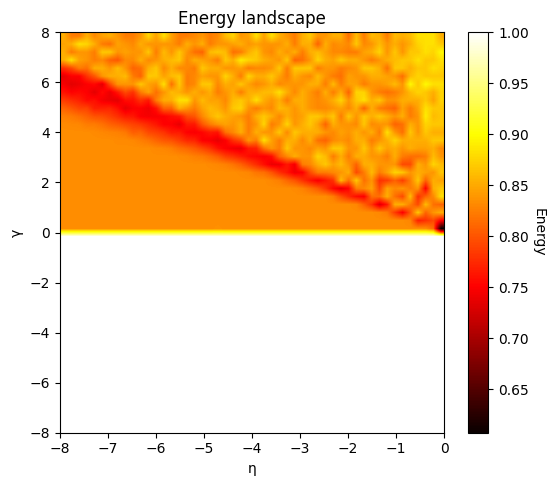

(<Figure size 620x520 with 2 Axes>,
 <Axes: title={'center': 'Energy landscape'}, xlabel='η', ylabel='γ'>)

In [27]:
plot_energy_landscape(eta_values, gamma_values, values_energy_landscape, 
                          title="Energy landscape") 

In [28]:
eta_values_short = eta_values.copy()
gamma_values_short = gamma_values.copy()
values_energy_landscape_short = values_energy_landscape.copy()

gamma_values_short_2 = gamma_values_short[gamma_values_short > -0.1]
values_energy_landscape_short_2 = values_energy_landscape_short[gamma_values_short > -0.1,:]


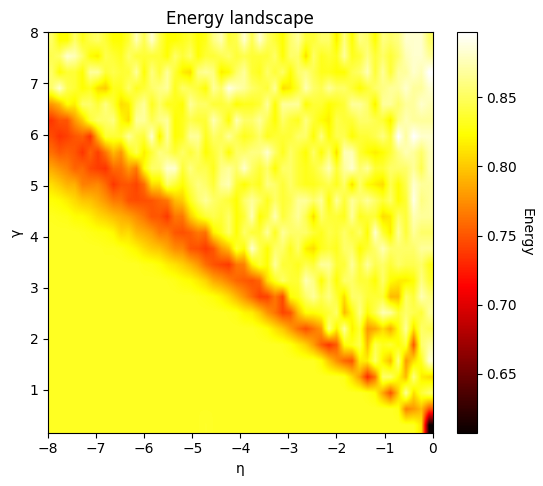

(<Figure size 620x520 with 2 Axes>,
 <Axes: title={'center': 'Energy landscape'}, xlabel='η', ylabel='γ'>)

In [29]:
plot_energy_landscape(eta_values_short, gamma_values_short_2, values_energy_landscape_short_2, 
                          title="Energy landscape") 

In [30]:
# connectomes_binarized = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/connectomes_binarized.npy")
# consensus_connectome_bin = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/consensus_connectome_bin.npy")
# all_connectomes = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/all_connectomes.npy")

# df_identifiers = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/df_identifiers.csv") 

# # df_graph_measures_bin = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/df_graph_measures_bin.csv")
# df_graph_measures_all = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/df_graph_measures_all.csv")
# df_graph_measures = df_graph_measures_all

In [ ]:
# eta_values, gamma_values, values_energy_landscape = load_energy_landscape
df = pd.read_csv("/Users/adrian/Documents/01_wprojects/14_4D_lab/output/02_gnm_estimation/gnm_grid_results_2025-08-08_01-00-55.csv")
df

,subject,eta,gamma,energy
0,0,-3.0,0.100000,0.220588
1,0,-3.0,0.126316,0.176471
2,0,-3.0,0.152632,0.161765
3,0,-3.0,0.178947,0.161765
4,0,-3.0,0.205263,0.235294
...,...,...,...,...
27995,68,0.0,0.494737,0.941176
27996,68,0.0,0.521053,0.941176
27997,68,0.0,0.547368,0.661765
27998,68,0.0,0.573684,0.941176


In [32]:
# # Turn this into a grid and plot it

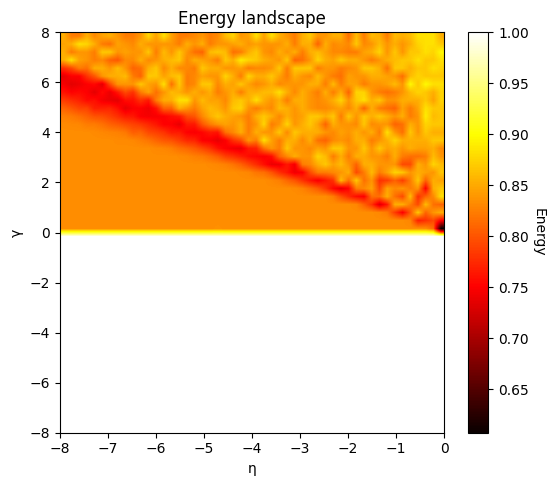

(<Figure size 620x520 with 2 Axes>,
 <Axes: title={'center': 'Energy landscape'}, xlabel='η', ylabel='γ'>)

In [33]:
plot_energy_landscape(eta_values, gamma_values, values_energy_landscape, 
                          title="Energy landscape") 

In [34]:
ROOT = "/Users/adrian/Documents/01_projects/14_4D_lab"
# conn = np.load(f"{ROOT}/data/preprocessed/01_first_analysises/connectomes_binarized.npy").T
# dist = np.load(f"{ROOT}/data/preprocessed/01_first_analysises/distance_matrix.npy")

# df_grid, df_best = run_gnm_full(conn, dist)

out_dir = f"{ROOT}/output/02_gnm_estimation"

In [35]:
# Die unten müssen erst geöffnet werden, aber ich weiß noch nicht wie. - Datum ändert sich ja immer.
# Danach:
    - Thema ausdenken für Kayson
    - Kurze Zusammenfassung machen was soweit passiert ist 
    - 
# 
# 
# 
# # Open the saved results, that start with this prefix: 
# df_grid = pd.read_csv(f"{out_dir}/gnm_grid_results_{time_stamp_for_saving()}.csv")
# df_best = pd.read_csv(f"{out_dir}/gnm_best_eval_{time_stamp_for_saving()}.csv") 

IndentationError: unexpected indent (1120888322.py, line 3)

# Plotting other results

In [75]:
graph_measures_empirical_connectomes = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/df_graph_measures_bin.csv")
graph_measures_empirical_connectomes = graph_measures_empirical_connectomes.sort_values("network_index")
graph_measures_empirical_connectomes

,Unnamed: 0,network_index,avg_communicability,global_efficiency,modularity,avg_clustering,avg_degree,transitivity,avg_edge_distance,char_path_length,richclub_n_edges,richclub_avg_length
0,0,0,0.020127,0.523178,0.385674,0.558604,11.441176,0.469829,45.503481,2.234416,41,53.039571
1,1,1,0.021016,0.559958,0.342192,0.552731,13.411765,0.457210,48.645978,2.046532,46,53.392462
2,2,2,0.021049,0.552275,0.418506,0.599042,13.411765,0.496317,47.508465,2.096576,47,60.049954
3,3,3,0.021261,0.556373,0.408566,0.570124,13.411765,0.469097,49.023596,2.069359,48,60.087251
4,4,4,0.020606,0.555897,0.336212,0.548212,13.411765,0.457649,48.363462,2.073749,52,52.655709
...,...,...,...,...,...,...,...,...,...,...,...,...
65,65,65,0.020709,0.559445,0.367106,0.566838,13.411765,0.469806,47.284030,2.049605,51,50.081903
66,66,66,0.020492,0.553995,0.402535,0.601771,13.411765,0.491271,46.985564,2.082529,51,57.814512
67,67,67,0.021370,0.558311,0.335142,0.558756,13.411765,0.469783,47.305744,2.056190,43,61.959989
68,68,68,0.021397,0.561509,0.342567,0.532443,13.411765,0.436678,47.695957,2.039508,44,52.333818


In [76]:
best_gnm_per_subject = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/output/02_gnm_estimation/gnm_best_eval_2025-08-08_01-17-21.csv")
# order by "subject" 
best_gnm_per_subject = best_gnm_per_subject.sort_values("subject")
best_gnm_per_subject

,subject,eta,gamma,energy,memory_capacity,sequence_recall,network_index,avg_communicability,global_efficiency,modularity,avg_clustering,avg_degree,transitivity,avg_edge_distance,char_path_length,richclub_n_edges,richclub_avg_length
0,0,-3.000000,0.152632,0.128535,"{'mc_mean': 1.0501359063453588, 'mc_std': 0.00...","{5: {'r2_mean': 0.9050766320488848, 'r2_std': ...",0,0.018427,0.449817,0.406341,0.492932,11.441176,0.518106,41.451730,2.200423,52,41.547116
2,1,-3.000000,0.152632,0.102941,"{'mc_mean': 1.052492757043535, 'mc_std': 0.008...","{5: {'r2_mean': 0.8860806592422724, 'r2_std': ...",0,0.020320,0.515108,0.320159,0.454020,13.411765,0.435115,44.085365,1.964286,52,46.990479
5,2,-3.000000,0.178947,0.161765,"{'mc_mean': 1.0457768440500357, 'mc_std': 0.00...","{5: {'r2_mean': 0.8179565798760826, 'r2_std': ...",0,0.018236,0.477941,0.327591,0.499860,13.411765,0.501518,43.938630,1.936066,64,45.236437
13,3,-2.526316,0.205263,0.117647,"{'mc_mean': 1.0507393745033984, 'mc_std': 0.00...","{5: {'r2_mean': 0.8350603511726995, 'r2_std': ...",0,0.015047,0.438181,0.356502,0.634753,13.411765,0.645413,53.053622,2.804067,79,51.892058
6,4,-3.000000,0.152632,0.116228,"{'mc_mean': 1.0494156553374387, 'mc_std': 0.00...","{5: {'r2_mean': 0.8909681954496451, 'r2_std': ...",0,0.019771,0.472271,0.286220,0.427677,13.411765,0.450562,44.145601,1.868362,53,44.930027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,65,-3.000000,0.178947,0.161765,"{'mc_mean': 1.043836054871625, 'mc_std': 0.008...","{5: {'r2_mean': 0.843930178605663, 'r2_std': 0...",0,0.018039,0.435323,0.329536,0.485098,13.411765,0.515810,44.390741,1.843985,53,45.772151
66,66,-2.684211,0.205263,0.205882,"{'mc_mean': 1.0506588348441106, 'mc_std': 0.00...","{5: {'r2_mean': 0.8543676420893476, 'r2_std': ...",0,0.015747,0.337723,0.243738,0.524349,13.411765,0.572891,50.423567,1.786348,67,52.170128
67,67,-3.000000,0.152632,0.147059,"{'mc_mean': 1.0527628733395888, 'mc_std': 0.00...","{5: {'r2_mean': 0.8795650026490268, 'r2_std': ...",0,0.020888,0.510243,0.394715,0.493931,13.411765,0.481542,41.481345,1.998016,49,46.221262
68,68,-2.684211,0.152632,0.132353,"{'mc_mean': 1.0471661732274986, 'mc_std': 0.00...","{5: {'r2_mean': 0.8702488675052287, 'r2_std': ...",0,0.018123,0.492135,0.300140,0.452666,13.411765,0.481221,46.210886,2.048643,65,45.809801


In [89]:
mean_r2_sr = {}

for subject in best_gnm_per_subject["sequence_recall"].values: 
    # turn the string into a dict
    subject = eval(subject)
    # print(subject)
    # print(subject.keys()) # dict keys 5,6,7,8,9,...,25 
    for key in subject.keys():
        if key not in mean_r2_sr:
            mean_r2_sr[key] = []
        mean_r2_sr[key].append(subject[key]["r2_mean"])

    # print(subject[5])
    # print(subject[5]["r2_mean"])

mean_r2_sr[6]

[0.508432389143497,
 0.7617202008173637,
 0.47712272415981677,
 0.4635387297841393,
 0.622998516746987,
 0.6819813826665578,
 0.6761587077623687,
 0.5995493829164684,
 0.5534931302601145,
 0.5617950603635773,
 0.4711644275171046,
 0.6180637513044923,
 0.6435888260926965,
 0.28047743785584667,
 0.5579516484325837,
 0.47181483694115844,
 0.6850100939403967,
 0.5885503247267998,
 0.5175425723050704,
 0.5577877225462584,
 0.637419116389396,
 0.4342602305981675,
 0.44792431617538114,
 0.5395705622027099,
 0.41352761558715023,
 0.6974760642764114,
 0.6041318119610102,
 0.5057573577204494,
 0.7262408317376196,
 0.3543333832405729,
 0.4391348218159668,
 0.5989773243050786,
 0.6929397815276443,
 0.5668638763453847,
 0.4418281966130646,
 0.6356072793982352,
 0.6384829881937923,
 0.5920631100453965,
 0.6222800752695751,
 0.5928245247665307,
 0.4551396915004494,
 0.6238585571677695,
 0.5483720428431976,
 0.5076290887414705,
 0.6597282906674135,
 0.4795052699821488,
 0.4901909037463734,
 0.69455206

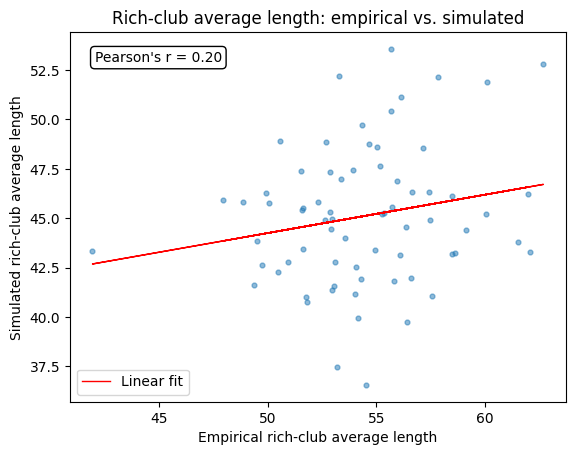

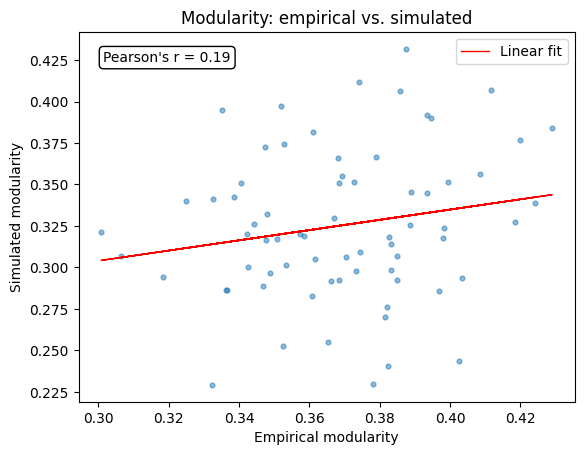

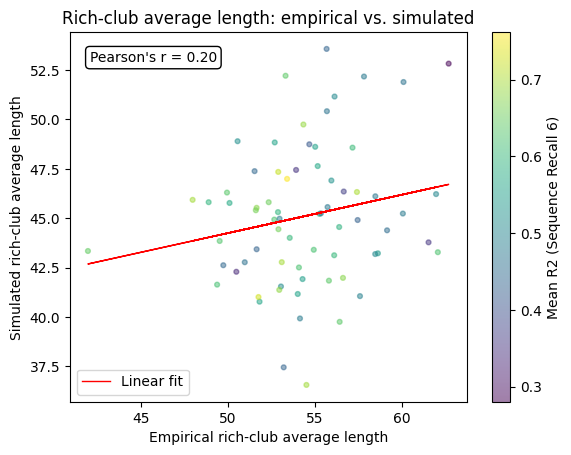

In [ ]:
# variable_name = "richclub_avg_length"

def plot_graph_measure_vs_simulated(graph_measures_empirical_connectomes, best_gnm_per_subject, variable_name, color_metric=None, color_metric_name=None):
    """ Plot a scatter plot of the empirical graph measure vs. the simulated one.
    """
    printable_name_dict = {
        "richclub_avg_length": "rich-club average length",
        "modularity": "modularity",
    }

    emp_values = graph_measures_empirical_connectomes[variable_name].values
    simulated_values = best_gnm_per_subject[variable_name].values

    if color_metric:
        plt.scatter(emp_values, simulated_values, c=color_metric, alpha=0.5, s=12)
        plt.colorbar(label=color_metric_name)
    else:
        plt.scatter(emp_values, simulated_values, alpha=0.5, s=12)

    plt.xlabel(f"Empirical {printable_name_dict[variable_name]}")
    plt.ylabel(f"Simulated {printable_name_dict[variable_name]}")
    # but here capitcalize the first letter
    plt.title(f"{printable_name_dict[variable_name].capitalize()}: empirical vs. simulated")

    # Add a note with pearsons correclation coefficient
    from scipy.stats import pearsonr
    corr, _ = pearsonr(emp_values, simulated_values)
    plt.annotate(f"Pearson's r = {corr:.2f}", xy=(0.05, 0.95), xycoords='axes fraction',
                fontsize=10, ha='left', va='top',
                #  bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white"))
                    bbox=dict(boxstyle="round, pad=0.3", edgecolor="black", facecolor="white"),
                    color="black")

    # draw linear regression line
    from sklearn.linear_model import LinearRegression
    X = emp_values.reshape(-1, 1)
    y = simulated_values.reshape(-1, 1)
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    plt.plot(emp_values, y_pred, color='red', linewidth=1, label='Linear fit')
    plt.legend()
    plt.show()

variable_name = "richclub_avg_length"
plot_graph_measure_vs_simulated(graph_measures_empirical_connectomes, best_gnm_per_subject, variable_name)

variable_name = "modularity"
plot_graph_measure_vs_simulated(graph_measures_empirical_connectomes, best_gnm_per_subject, variable_name)

plot_graph_measure_vs_simulated(graph_measures_empirical_connectomes, best_gnm_per_subject, variable_name, color_metric=mean_r2_sr[6], color_metric_name="Mean R2 (Sequence Recall 6)")


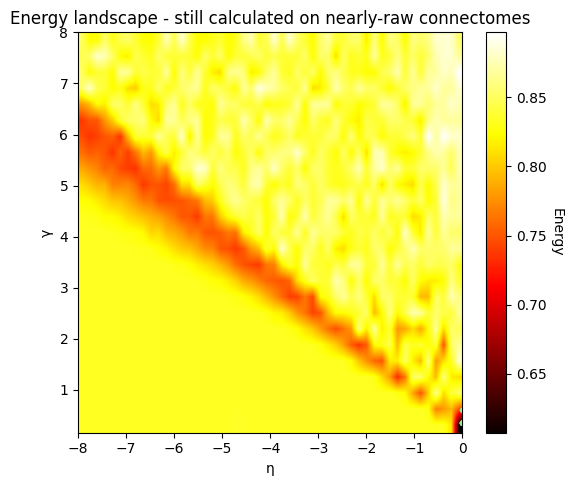

(<Figure size 620x520 with 2 Axes>,
 <Axes: title={'center': 'Energy landscape - still calculated on nearly-raw connectomes'}, xlabel='η', ylabel='γ'>)

In [72]:
old_best_params = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/output/00_first_energy_grids/gnm_best_params.csv")
plot_energy_landscape(eta_values_short, gamma_values_short_2, values_energy_landscape_short_2, old_best_params, #  best_gnm_per_subject,
                      dot_color="lightgreen", 
                      title="Energy landscape - still calculated on nearly-raw connectomes") 